## RDUH P2 Pathway Planner

This model aims to test a new intervention for P2 beds
The model runs in days

BASE: This is the current set-up
Spot: share 0.7, LOS 56 days, beds 242
Block: share 0.3, LOS 46 days, beds 85

PROPOSED: This is the proposed set-up
Spot: share 0.2, LOS 56 days, beds 69
Non RDUH Block: share 0.5, LOS 46 days, beds 135
RDUH Block: share 0.3, LOS 24 days, beds 48

### Assumptions:

Exponential inter-arrival times;
Lognormal service times

We don't have stdev, so we will assume a CV (coefficient of variation) such that sd = CV * mean and set to 0.2. Sensitivity to CV can be done.

In [63]:
import simpy
import numpy as np
import copy
import pandas as pd
import matplotlib.pyplot as plt

### Parameters

In [28]:
def lognormal_params_from_mean_cv(mean, cv):
    sd = cv * mean
    sigma2 = np.log(1 + (sd**2 / mean**2))
    sigma = np.sqrt(sigma2)
    mu = np.log(mean) - 0.5 * sigma2
    return {
        "mean_service_days": mean,
        "cv": cv,
        "sd_service_days": sd,
        "meanlog": mu,
        "sdlog": sigma,
    }
                
CV_DEFAULT = 0.2

PARAMS_BASE = {
    "random_seeds": {
        "arrivals": 100,
        "spot": 200,
        "non_rduh_block": 300,
        "rduh_block": 400,
    },
    "warm_up_days": 180,
    "results_days": 365,
    "mean_interarrival_days": 365 / 2253,
    "pathways": {
        "spot": {
            "capacity": 242,
            **lognormal_params_from_mean_cv(56, CV_DEFAULT),
        },
        "non_rduh_block": {
            "capacity": 85,
            **lognormal_params_from_mean_cv(46, CV_DEFAULT),
        },
        "rduh_block": {
            "capacity": 0,
            **lognormal_params_from_mean_cv(24, CV_DEFAULT),
        },
    }
}

PARAMS_PROPOSED = {
    "random_seeds": {
        "arrivals": 100,
        "spot": 200,
        "non_rduh_block": 300,
        "rduh_block": 400,
    },
    "warm_up_days": 180,
    "results_days": 365,
    "mean_interarrival_days": 365 / 2253,
    "pathways": {
        "spot": {
            "capacity": 69,
            **lognormal_params_from_mean_cv(56, CV_DEFAULT),
        },
        "non_rduh_block": {
            "capacity": 135,
            **lognormal_params_from_mean_cv(46, CV_DEFAULT),
        },
        "rduh_block": {
            "capacity": 48,
            **lognormal_params_from_mean_cv(24, CV_DEFAULT),
        },
    }
}

### Run single and mulitple reps

In [29]:
def run_one_replication(params):
    env = simpy.Environment()
    model = P2Model(env, params)

    env.process(model.arrival_generator())
    env.process(model.warmup_reset_process())

    total_runtime = params["warm_up_days"] + params["results_days"]
    env.run(until=total_runtime)

    return model.summary()

In [30]:
def run_replications(base_params, n_reps=10):
    all_results = []

    for rep in range(n_reps):
        params = copy.deepcopy(base_params)

        # Change seeds between replications
        #params["random_seeds"]["arrivals"] += rep
        params["random_seeds"]["spot"] += rep
        params["random_seeds"]["non_rduh_block"] += rep
        params["random_seeds"]["rduh_block"] += rep

        result = run_one_replication(params)
        result["replication"] = rep + 1
        all_results.append(result)

    return all_results

### Model

In [31]:
class P2Model:
    def __init__(self, env, params):
        self.env = env
        self.params = params
        seeds = params["random_seeds"]

        self.rng_arrivals = np.random.default_rng(seeds["arrivals"])
        
        self.rng_service = {
            name: np.random.default_rng(seeds[name])
            for name in params["pathways"]
        }

        # Fixed priority order
        self.pathway_order = ["rduh_block", "non_rduh_block", "spot"]

        # Build only active resources
        self.streams = {
            name: simpy.Resource(env, capacity=p["capacity"])
            for name, p in params["pathways"].items()
            if p["capacity"] > 0
        }

        # Queue tracking
        self.current_queue = 0
        self.max_queue = 0
        self.queue_area = 0.0
        self.last_queue_change_time = 0.0

        # Occupancy tracking by pathway
        self.current_occupancy = {name: 0 for name in self.streams}
        self.max_occupancy = {name: 0 for name in self.streams}
        self.occupancy_area = {name: 0.0 for name in self.streams}
        self.last_occupancy_change_time = {name: 0.0 for name in self.streams}

        self.results = {
            "arrival_times": [],
            "service_start_times": [],
            "departure_times": [],
            "waiting_times": [],
            "time_in_system": [],
            "assigned_stream": [],
            "queued_flag": [],
        }

        self.patient_count = 0

    def recordable(self):
        return self.env.now >= self.params["warm_up_days"]

    def update_queue_stats(self):
        elapsed = self.env.now - self.last_queue_change_time
        self.queue_area += self.current_queue * elapsed
        self.last_queue_change_time = self.env.now

    def increment_queue(self):
        self.update_queue_stats()
        self.current_queue += 1
        self.max_queue = max(self.max_queue, self.current_queue)

    def decrement_queue(self):
        self.update_queue_stats()
        self.current_queue -= 1

    def update_occupancy_stats(self, stream_name):
        elapsed = self.env.now - self.last_occupancy_change_time[stream_name]
        self.occupancy_area[stream_name] += self.current_occupancy[stream_name] * elapsed
        self.last_occupancy_change_time[stream_name] = self.env.now

    def increment_occupancy(self, stream_name):
        self.update_occupancy_stats(stream_name)
        self.current_occupancy[stream_name] += 1
        self.max_occupancy[stream_name] = max(
            self.max_occupancy[stream_name],
            self.current_occupancy[stream_name]
        )

    def decrement_occupancy(self, stream_name):
        self.update_occupancy_stats(stream_name)
        self.current_occupancy[stream_name] -= 1

    def sample_interarrival(self):
        mean = self.params["mean_interarrival_days"]
        return self.rng_arrivals.exponential(mean)

    def sample_service_time(self, stream_name):
        p = self.params["pathways"][stream_name]
        rng = self.rng_service[stream_name]
        return rng.lognormal(mean=p["meanlog"], sigma=p["sdlog"])

    def choose_stream_or_queue(self):
        """
        Check pathways in priority order.
        Return the first available active stream, otherwise None.
        """
        for stream_name in self.pathway_order:
            if stream_name not in self.streams:
                continue

            resource = self.streams[stream_name]
            if resource.count < resource.capacity:
                return stream_name

        return None

    def patient_process(self, patient_id):           
        arrival_time = self.env.now
        
        if self.recordable():
            self.results["arrival_times"].append(arrival_time)

        chosen_stream = self.choose_stream_or_queue()
        queued = False

        if chosen_stream is not None:
            resource = self.streams[chosen_stream]
            with resource.request() as req:
                yield req

                self.increment_occupancy(chosen_stream)

                service_start = self.env.now
                wait = service_start - arrival_time
                service_time = self.sample_service_time(chosen_stream)
                if self.recordable():
                    self.results["service_start_times"].append(service_start)
                    self.results["waiting_times"].append(wait)
                    self.results["assigned_stream"].append(chosen_stream)
                    self.results["queued_flag"].append(queued)

                yield self.env.timeout(service_time)

                departure_time = self.env.now
                self.decrement_occupancy(chosen_stream)
                
                if self.recordable():
                    self.results["departure_times"].append(departure_time)
                    self.results["time_in_system"].append(departure_time - arrival_time)

        else:
            queued = True

            self.increment_queue()

            while True:
                chosen_stream = self.choose_stream_or_queue()

                if chosen_stream is not None:
                    resource = self.streams[chosen_stream]
                    with resource.request() as req:
                        yield req

                        self.decrement_queue()
                        self.increment_occupancy(chosen_stream)

                        service_start = self.env.now
                        wait = service_start - arrival_time
                        service_time = self.sample_service_time(chosen_stream)
                        if self.recordable():
                            self.results["service_start_times"].append(service_start)
                            self.results["waiting_times"].append(wait)
                            self.results["assigned_stream"].append(chosen_stream)
                            self.results["queued_flag"].append(queued)

                        yield self.env.timeout(service_time)

                        departure_time = self.env.now
                        self.decrement_occupancy(chosen_stream)
                        
                        if self.recordable():
                            self.results["departure_times"].append(departure_time)
                            self.results["time_in_system"].append(departure_time - arrival_time)

                    break

                yield self.env.timeout(0.01)

    def warmup_reset_process(self):
        yield self.env.timeout(self.params["warm_up_days"])
        self.reset_tracking()

    def arrival_generator(self):
        while True:
            self.patient_count += 1
            self.env.process(self.patient_process(self.patient_count))
            yield self.env.timeout(self.sample_interarrival())

    def reset_tracking(self):
        # Reset queue stats
        self.queue_area = 0.0
        self.max_queue = self.current_queue
        self.last_queue_change_time = self.env.now
    
        # Reset occupancy stats
        for name in self.streams:
            self.occupancy_area[name] = 0.0
            self.max_occupancy[name] = self.current_occupancy[name]
            self.last_occupancy_change_time[name] = self.env.now

        # Reset recorded outputs
        self.results = {
            "arrival_times": [],
            "service_start_times": [],
            "departure_times": [],
            "waiting_times": [],
            "time_in_system": [],
            "assigned_stream": [],
            "queued_flag": [],
        }

    def summary(self):
        n = len(self.results["assigned_stream"])
        if n == 0:
            return {"patients_completed": 0}

        assigned = self.results["assigned_stream"]
        queued = self.results["queued_flag"]

        self.update_queue_stats()
        for name in self.streams:
            self.update_occupancy_stats(name)

        total_bed_days = sum(self.occupancy_area.values())

        observed_time = self.params["results_days"]

        summary = {
            "patients_completed": n,
            "mean_waiting_time": float(np.mean(self.results["waiting_times"])),
            "mean_time_in_system": float(np.mean(self.results["time_in_system"])),
            "prop_queued": float(np.mean(queued)),
            "mean_queue_length": self.queue_area / observed_time,
            "max_queue_length": self.max_queue, 
            "total_bed_days": total_bed_days,
            #"spot_count": assigned.count("spot"),
            #"non_rduh_block_count": assigned.count("non_rduh_block"),
            #"rduh_block_count": assigned.count("rduh_block"),
        }

        for name in self.pathway_order:
            summary[f"{name}_count"] = assigned.count(name)

            if name in self.streams:
                summary[f"{name}_bed_days"] = self.occupancy_area[name] if name in self.streams else 0.0
                summary[f"{name}_mean_occupancy"] = self.occupancy_area[name] / observed_time
                summary[f"{name}_max_occupancy"] = self.max_occupancy[name]
                summary[f"{name}_utilisation"] = (
                    self.occupancy_area[name] / (observed_time * self.params["pathways"][name]["capacity"])
                )
            else:
                summary[f"{name}_bed_days"] = 0.0
                summary[f"{name}_mean_occupancy"] = 0.0
                summary[f"{name}_max_occupancy"] = 0
                summary[f"{name}_utilisation"] = 0.0

        return summary


# BASE CASE RESULTS

In [48]:
if __name__ == "__main__":
    results = run_replications(PARAMS_BASE, n_reps=20)

    def mean_sd(arr):
        return np.mean(arr), np.std(arr)

    def mean_ci(arr):
        arr = np.array(arr)
        mean = np.mean(arr)
        se = np.std(arr, ddof=1) / np.sqrt(len(arr))
        ci = 1.96 * se
        return mean, ci

    # PERFORMANCE METRICS
    wait_mean, wait_sd = mean_sd([r["mean_waiting_time"] for r in results])
    queue_mean, queue_sd = mean_sd([r["mean_queue_length"] for r in results])
    tis_mean, tis_sd = mean_sd([r["mean_time_in_system"] for r in results])
    bed_mean, bed_sd = mean_sd([r["total_bed_days"] for r in results])

    # PATHWAY COUNTS
    spot_counts = [r["spot_count"] for r in results]
    non_rduh_counts = [r["non_rduh_block_count"] for r in results]
    rduh_counts = [r["rduh_block_count"] for r in results]

    mean_spot = np.mean(spot_counts)
    mean_non_rduh = np.mean(non_rduh_counts)
    mean_rduh = np.mean(rduh_counts)

    total_mean = mean_spot + mean_non_rduh + mean_rduh

    # BUILD TABLE 1 (PERFORMANCE)
    performance_table = pd.DataFrame({
        "Metric": [
            "Waiting time (days)",
            "Queue length (patients)",
            "Time in system (days)",
            "Total bed-days"
        ],
        "Mean ± SD": [
            f"{wait_mean:.2f} ± {wait_sd:.2f}",
            f"{queue_mean:.2f} ± {queue_sd:.2f}",
            f"{tis_mean:.2f} ± {tis_sd:.2f}",
            f"{bed_mean:.0f} ± {bed_sd:.0f}"
        ]
    })

    # BUILD TABLE 2 (PATHWAYS)
    pathway_table = pd.DataFrame({
        "Pathway": ["Spot", "Non-RDUH block", "RDUH block"],
        "Mean Patients": [
            f"{mean_spot:.0f}",
            f"{mean_non_rduh:.0f}",
            f"{mean_rduh:.0f}"
        ],
        "Proportion": [
            f"{mean_spot / total_mean:.1%}",
            f"{mean_non_rduh / total_mean:.1%}",
            f"{mean_rduh / total_mean:.1%}"
        ]
    })

    # PRINT TABLES
    print("\n=== PERFORMANCE SUMMARY ===")
    print(performance_table.to_string(index=False))

    print("\n=== PATHWAY SPLIT ===")
    print(pathway_table.to_string(index=False))


=== PERFORMANCE SUMMARY ===
                 Metric    Mean ± SD
    Waiting time (days)  8.88 ± 0.68
Queue length (patients) 59.69 ± 5.19
  Time in system (days) 59.77 ± 0.62
         Total bed-days  119347 ± 13

=== PATHWAY SPLIT ===
       Pathway Mean Patients Proportion
          Spot          1572      70.0%
Non-RDUH block           673      30.0%
    RDUH block             0       0.0%


# PROPOSED CASE RESULTS

In [49]:
if __name__ == "__main__":
    results = run_replications(PARAMS_PROPOSED, n_reps=20)

    def mean_sd(arr):
        return np.mean(arr), np.std(arr)

    def mean_ci(arr):
        arr = np.array(arr)
        mean = np.mean(arr)
        se = np.std(arr, ddof=1) / np.sqrt(len(arr))
        ci = 1.96 * se
        return mean, ci

    # PERFORMANCE METRICS
    wait_mean, wait_sd = mean_sd([r["mean_waiting_time"] for r in results])
    queue_mean, queue_sd = mean_sd([r["mean_queue_length"] for r in results])
    tis_mean, tis_sd = mean_sd([r["mean_time_in_system"] for r in results])
    bed_mean, bed_sd = mean_sd([r["total_bed_days"] for r in results])

    # PATHWAY COUNTS
    spot_counts = [r["spot_count"] for r in results]
    non_rduh_counts = [r["non_rduh_block_count"] for r in results]
    rduh_counts = [r["rduh_block_count"] for r in results]

    mean_spot = np.mean(spot_counts)
    mean_non_rduh = np.mean(non_rduh_counts)
    mean_rduh = np.mean(rduh_counts)

    total_mean = mean_spot + mean_non_rduh + mean_rduh

    # BUILD TABLE 1 (PERFORMANCE)
    performance_table = pd.DataFrame({
        "Metric": [
            "Waiting time (days)",
            "Queue length (patients)",
            "Time in system (days)",
            "Total bed-days"
        ],
        "Mean ± SD": [
            f"{wait_mean:.2f} ± {wait_sd:.2f}",
            f"{queue_mean:.2f} ± {queue_sd:.2f}",
            f"{tis_mean:.2f} ± {tis_sd:.2f}",
            f"{bed_mean:.0f} ± {bed_sd:.0f}"
        ]
    })

    # BUILD TABLE 2 (PATHWAYS)
    pathway_table = pd.DataFrame({
        "Pathway": ["Spot", "Non-RDUH block", "RDUH block"],
        "Mean Patients": [
            f"{mean_spot:.0f}",
            f"{mean_non_rduh:.0f}",
            f"{mean_rduh:.0f}"
        ],
        "Proportion": [
            f"{mean_spot / total_mean:.1%}",
            f"{mean_non_rduh / total_mean:.1%}",
            f"{mean_rduh / total_mean:.1%}"
        ]
    })

    # PRINT TABLES
    print("\n=== PERFORMANCE SUMMARY ===")
    print(performance_table.to_string(index=False))

    print("\n=== PATHWAY SPLIT ===")
    print(pathway_table.to_string(index=False))


=== PERFORMANCE SUMMARY ===
                 Metric    Mean ± SD
    Waiting time (days)  8.96 ± 0.70
Queue length (patients) 60.21 ± 5.23
  Time in system (days) 48.06 ± 0.72
         Total bed-days    91977 ± 5

=== PATHWAY SPLIT ===
       Pathway Mean Patients Proportion
          Spot           448      19.9%
Non-RDUH block          1069      47.6%
    RDUH block           730      32.5%


In [34]:
results = run_replications(PARAMS_BASE, n_reps=5)
for r in results:
    print(r["replication"], r["mean_waiting_time"], r["mean_queue_length"])

1 8.976756756748594 58.95060199610687
2 9.501287572894007 62.791494352342895
3 8.652691281130922 57.60426867512903
4 8.157536617835458 54.523472898456326
5 7.94389575971009 52.14202624971242


# PROPOSED CASE WITH EXTRA BEDS

In [50]:
def run_capacity_sensitivity(base_params, extra_beds_to_test, n_reps=20, add_to="rduh_block"):
    all_results = []

    for extra in extra_beds_to_test:
        params = copy.deepcopy(base_params)
        params["pathways"][add_to]["capacity"] += extra

        results = run_replications(params, n_reps=n_reps)

        wait_vals = [r["mean_waiting_time"] for r in results]
        queue_vals = [r["mean_queue_length"] for r in results]
        tis_vals = [r["mean_time_in_system"] for r in results]
        bed_vals = [r["total_bed_days"] for r in results]

        summary = {
            "extra_beds": extra,
            "pathway": add_to,

            "mean_waiting_time": np.mean(wait_vals),
            "sd_waiting_time": np.std(wait_vals, ddof=1),

            "mean_queue_length": np.mean(queue_vals),
            "sd_queue_length": np.std(queue_vals, ddof=1),

            "mean_time_in_system": np.mean(tis_vals),
            "sd_time_in_system": np.std(tis_vals, ddof=1),

            "total_bed_days": np.mean(bed_vals),
            "sd_total_bed_days": np.std(bed_vals, ddof=1),
        }

        all_results.append(summary)

    return all_results

In [51]:
results_rduh = run_capacity_sensitivity(
    PARAMS_PROPOSED,
    extra_beds_to_test=[0, 2, 4, 6, 8, 10],
    n_reps=20,
    add_to="rduh_block"
)

for r in results_rduh:
    print(r)

{'extra_beds': 0, 'pathway': 'rduh_block', 'mean_waiting_time': 8.955017841814964, 'sd_waiting_time': 0.7172513271929186, 'mean_queue_length': 60.207346207687635, 'sd_queue_length': 5.3608614204877565, 'mean_time_in_system': 48.06052255364912, 'sd_time_in_system': 0.741473848561381, 'total_bed_days': 91976.66691662802, 'sd_total_bed_days': 5.01778191514829}
{'extra_beds': 2, 'pathway': 'rduh_block', 'mean_waiting_time': 6.579424028940734, 'sd_waiting_time': 0.8386351008266829, 'mean_queue_length': 42.535795336363435, 'sd_queue_length': 5.4262416079884765, 'mean_time_in_system': 46.112624811835985, 'sd_time_in_system': 0.8139386985524767, 'total_bed_days': 92693.5646030948, 'sd_total_bed_days': 14.971915571856595}
{'extra_beds': 4, 'pathway': 'rduh_block', 'mean_waiting_time': 4.085316667424995, 'sd_waiting_time': 0.798661151308065, 'mean_queue_length': 25.979159529438768, 'sd_queue_length': 5.123522103233244, 'mean_time_in_system': 43.95518239494886, 'sd_time_in_system': 0.786709106418

### Plots

In [52]:
df = pd.DataFrame(results_rduh)
print(df)

   extra_beds     pathway  mean_waiting_time  sd_waiting_time  \
0           0  rduh_block           8.955018         0.717251   
1           2  rduh_block           6.579424         0.838635   
2           4  rduh_block           4.085317         0.798661   
3           6  rduh_block           2.093551         0.581298   
4           8  rduh_block           1.066773         0.312535   
5          10  rduh_block           0.623812         0.159554   

   mean_queue_length  sd_queue_length  mean_time_in_system  sd_time_in_system  \
0          60.207346         5.360861            48.060523           0.741474   
1          42.535795         5.426242            46.112625           0.813939   
2          25.979160         5.123522            43.955182           0.786709   
3          13.300700         3.692408            42.087184           0.661995   
4           6.777664         1.985666            40.834055           0.459422   
5           3.963341         1.013717            40.045204

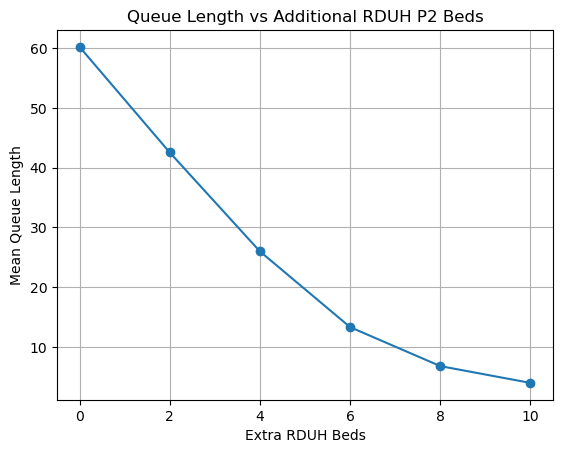

In [53]:
plt.figure()

plt.plot(df["extra_beds"], df["mean_queue_length"], marker='o')

plt.xlabel("Extra RDUH Beds")
plt.ylabel("Mean Queue Length")
plt.title("Queue Length vs Additional RDUH P2 Beds")

plt.grid()
plt.show()

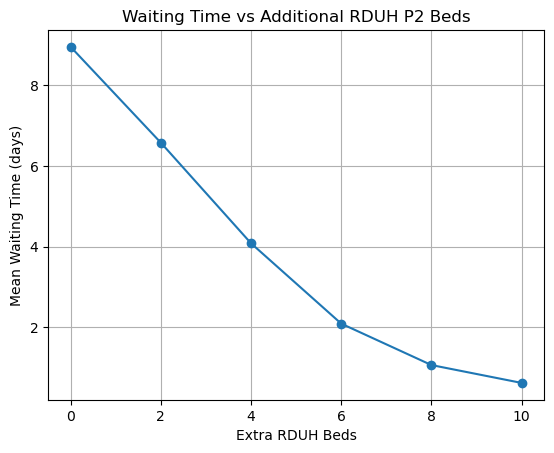

In [54]:
plt.figure()

plt.plot(df["extra_beds"], df["mean_waiting_time"], marker='o')

plt.xlabel("Extra RDUH Beds")
plt.ylabel("Mean Waiting Time (days)")
plt.title("Waiting Time vs Additional RDUH P2 Beds")

plt.grid()
plt.show()

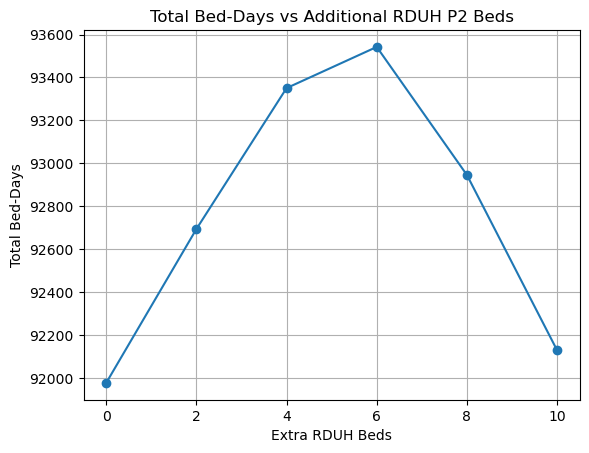

In [55]:
plt.figure()

plt.plot(df["extra_beds"], df["total_bed_days"], marker='o')

plt.xlabel("Extra RDUH Beds")
plt.ylabel("Total Bed-Days")
plt.title("Total Bed-Days vs Additional RDUH P2 Beds")

plt.grid()
plt.show()

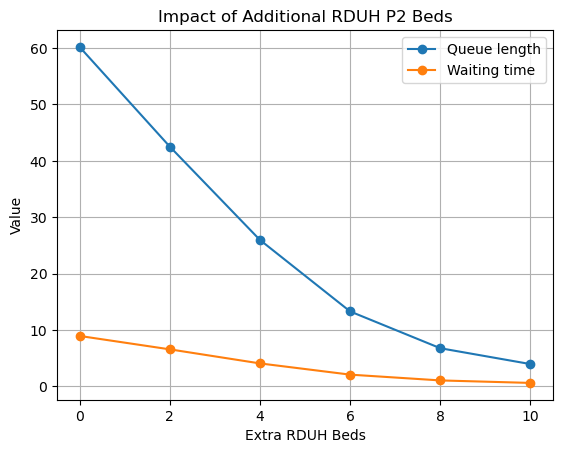

In [56]:
plt.figure()

plt.plot(df["extra_beds"], df["mean_queue_length"], marker='o', label="Queue length")
plt.plot(df["extra_beds"], df["mean_waiting_time"], marker='o', label="Waiting time")

plt.xlabel("Extra RDUH Beds")
plt.ylabel("Value")
plt.title("Impact of Additional RDUH P2 Beds")

plt.legend()
plt.grid()

plt.show()

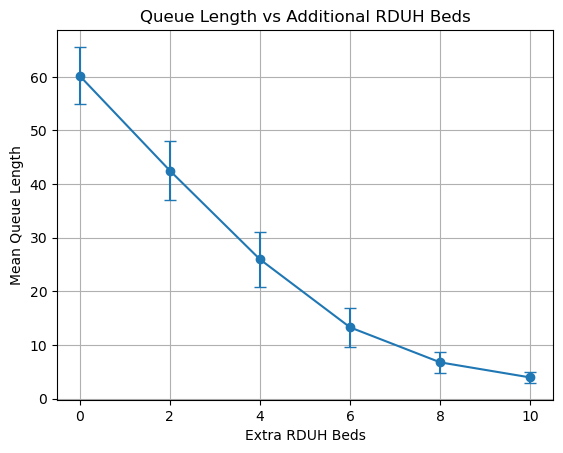

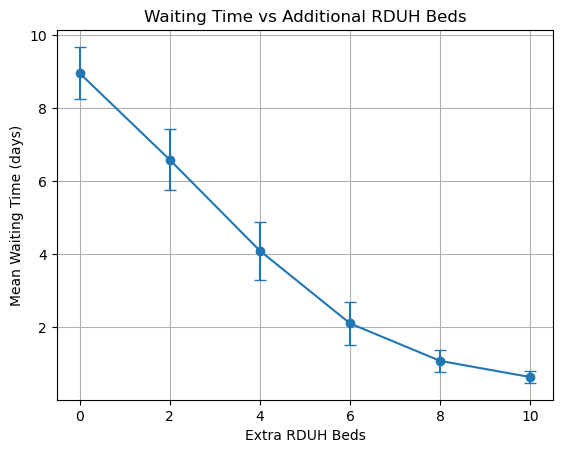

In [57]:
plt.figure()
plt.errorbar(
    df["extra_beds"],
    df["mean_queue_length"],
    yerr=df["sd_queue_length"],
    marker="o",
    capsize=4
)
plt.xlabel("Extra RDUH Beds")
plt.ylabel("Mean Queue Length")
plt.title("Queue Length vs Additional RDUH Beds")
plt.grid()
plt.show()

plt.figure()
plt.errorbar(
    df["extra_beds"],
    df["mean_waiting_time"],
    yerr=df["sd_waiting_time"],
    marker="o",
    capsize=4
)
plt.xlabel("Extra RDUH Beds")
plt.ylabel("Mean Waiting Time (days)")
plt.title("Waiting Time vs Additional RDUH Beds")
plt.grid()
plt.show()

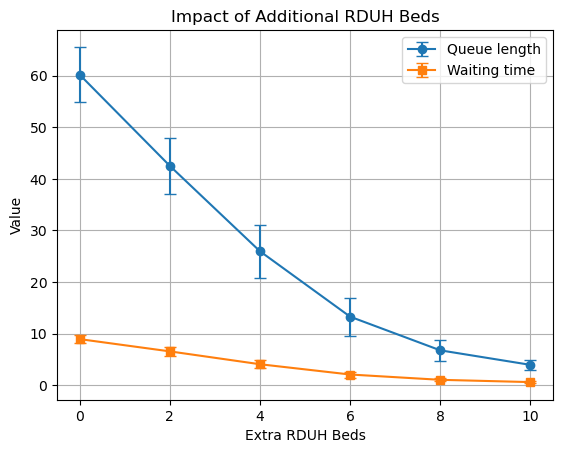

In [58]:
plt.figure()
plt.errorbar(
    df["extra_beds"],
    df["mean_queue_length"],
    yerr=df["sd_queue_length"],
    marker="o",
    capsize=4,
    label="Queue length"
)
plt.errorbar(
    df["extra_beds"],
    df["mean_waiting_time"],
    yerr=df["sd_waiting_time"],
    marker="s",
    capsize=4,
    label="Waiting time"
)
plt.xlabel("Extra RDUH Beds")
plt.ylabel("Value")
plt.title("Impact of Additional RDUH Beds")
plt.legend()
plt.grid()
plt.show()

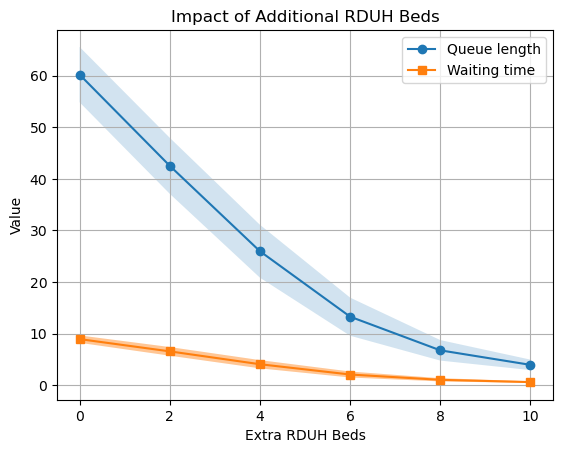

In [62]:
plt.figure()

# Queue length
plt.plot(df["extra_beds"], df["mean_queue_length"], marker="o", label="Queue length")
plt.fill_between(
    df["extra_beds"],
    df["mean_queue_length"] - df["sd_queue_length"],
    df["mean_queue_length"] + df["sd_queue_length"],
    alpha=0.2
)

# Waiting time
plt.plot(df["extra_beds"], df["mean_waiting_time"], marker="s", label="Waiting time")
plt.fill_between(
    df["extra_beds"],
    df["mean_waiting_time"] - df["sd_waiting_time"],
    df["mean_waiting_time"] + df["sd_waiting_time"],
    alpha=0.44
)

plt.xlabel("Extra RDUH Beds")
plt.ylabel("Value")
plt.title("Impact of Additional RDUH Beds")
plt.legend()
plt.grid()

plt.show()